# Чтение и запись данных

## Чтение из баз данных с помощью pandas и sqlalchemy

### Проверка практики

### Подключение к БД

In [7]:
import sqlalchemy


In [14]:
#conn = 'mssql+pyodbc://username:VRA/user0907'
conn = 'mssql+pyodbc://db23/витринаданных?trusted_connection=yes&driver=SQL+Server'

In [11]:
import platform
print(f"Python version: {platform.python_version()}")
print(f"Python architecture: {platform.architecture()[0]}")

Python version: 3.13.5
Python architecture: 64bit


In [20]:
import pyodbc

# Получите список доступных драйверов
drivers = [x for x in pyodbc.drivers() if 'SQL Server' in x]
print("Available SQL Server drivers:", drivers)

Available SQL Server drivers: ['SQL Server']


In [21]:
import pyodbc
print(pyodbc.drivers())  # Покажет все доступные драйверы

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'PostgreSQL ANSI(x64)', 'PostgreSQL ANSI', 'PostgreSQL Unicode(x64)', 'PostgreSQL Unicode']


In [30]:
import sqlalchemy
from sqlalchemy import create_engine

# Вариант 1: Использование строки подключения SQLAlchemy
connection_string = "mssql+pyodbc://db23/витринаданных?trusted_connection=yes&driver=SQL+Server"
engine = create_engine(connection_string)

# Вариант 2: Явное создание URL объекта
from sqlalchemy import URL

url_object = URL.create(
    drivername="mssql+pyodbc",
    host="db23",
    database="витринаданных",
    query={"trusted_connection": "yes", "driver": "SQL Server"}
)
engine = create_engine(url_object)

# Проверка подключения
with engine.connect() as connection:
    print("Подключение через SQLAlchemy успешно!")

Подключение через SQLAlchemy успешно!


In [10]:
import pandas as pd
from sqlalchemy import create_engine

# Создаем движок SQLAlchemy
connection_string = "mssql+pyodbc://db23/витринаданных?trusted_connection=yes&driver=SQL+Server"
engine = create_engine(connection_string)

# Выполняем запрос к вашей таблице
try:
    with engine.connect() as conn:
        df = pd.read_sql(
            "SELECT * FROM [витринаданных].[dbo].[План_факт_кз]", 
            conn
        )
        print(f"Успешно загружено {len(df)} строк")
        print(df.head(10))
        
except Exception as e:
    print(f"Ошибка при выполнении запроса: {e}")

Успешно загружено 63209 строк
                  Номер        дата              Номер КЗ  \
0  00000000010           2024-01-03  ВРА00000001            
1  00000000010           2024-01-03  ВРА00000001            
2  00000000010           2024-01-03  ВРА00000001            
3  00000000010           2024-01-03  ВРА00000001            
4  00000000010           2024-01-03  ВРА00000001            
5  00000000010           2024-01-03  ВРА00000001            
6  00000000010           2024-01-03  ВРА00000001            
7  00000000002           2024-01-03  ВРА00000002            
8  00000000007           2024-01-04  ВРА00000002            
9  00000000007           2024-01-04  ВРА00000002            

                          Участок    Площадка Виды_операций Виды_номенклатуры  \
0  Участок производства сметаны 1  СПК                             Продукция    
1  Участок производства сметаны 1  СПК                             Продукция    
2  Участок производства сметаны 1  СПК                 

In [11]:

# Создаем движок SQLAlchemy
connection_string = "mssql+pyodbc://db23/витринаданных?trusted_connection=yes&driver=SQL+Server"
engine = create_engine(connection_string)

In [12]:
#df = pd.read_sql("select * from [витринаданных].[dbo].[План_факт_кз]", connect)
# Выполняем запрос к вашей таблице
try:
    with engine.connect() as conn:
        df = pd.read_sql(
            "SELECT * FROM [витринаданных].[dbo].[План_факт_кз]", 
            conn
        )
        print(df.head(10))
        
except Exception as e:
    print(f"Ошибка при выполнении запроса: {e}")


                  Номер        дата              Номер КЗ  \
0  00000000010           2024-01-03  ВРА00000001            
1  00000000010           2024-01-03  ВРА00000001            
2  00000000010           2024-01-03  ВРА00000001            
3  00000000010           2024-01-03  ВРА00000001            
4  00000000010           2024-01-03  ВРА00000001            
5  00000000010           2024-01-03  ВРА00000001            
6  00000000010           2024-01-03  ВРА00000001            
7  00000000002           2024-01-03  ВРА00000002            
8  00000000007           2024-01-04  ВРА00000002            
9  00000000007           2024-01-04  ВРА00000002            

                          Участок    Площадка Виды_операций Виды_номенклатуры  \
0  Участок производства сметаны 1  СПК                             Продукция    
1  Участок производства сметаны 1  СПК                             Продукция    
2  Участок производства сметаны 1  СПК                             Продукция    
3  У

In [13]:
df = df.iloc[1:,:]
df

,Номер,дата,Номер КЗ,Участок,Площадка,Виды_операций,Виды_номенклатуры,Номенклатура,План,Факт,Отклонение,Причина_недопоставки,Причина_причины,Ответственное подразделение,План_базовый,Комментарий,Дата документа,Вид_оборудования,Вид_оборудования_назв
1,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,Десерт ЙLine.10%.банан.350г.ст.12шт,289.8,289.8,0.0,,,,289.80,,2024-01-04,b'\x820\x00\x15]\x03\xa1\\\x11\xed\xdfV\x9d\xf...,Фасовочный автомат «АДНК»
2,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.2,5%.с киви.двухсл.350г.ст.12шт",848.4,848.4,0.0,,,,848.40,,2024-01-04,b'\x820\x00\x15]\x03\xa1\\\x11\xed\xdfV\x9d\xf...,Фасовочный автомат «АДНК»
3,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с черникой.двухсл.350г.ст.12шт",726.6,726.6,0.0,,,,726.60,,2024-01-04,b'\x820\x00\x15]\x03\xa1\\\x11\xed\xdfV\x9d\xf...,Фасовочный автомат «АДНК»
4,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с вишн.двухсл.350г.ст.12шт",189.0,189.0,0.0,,,,189.00,,2024-01-04,b'\x820\x00\x15]\x03\xa1\\\x11\xed\xdfV\x9d\xf...,Фасовочный автомат «АДНК»
5,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с киви.двухсл.350г.ст.12шт",747.6,806.4,58.8,Перепроизводство,"Остаток с оборудования (линия, танк)",Служба производства 1,747.60,,2024-01-04,b'\x820\x00\x15]\x03\xa1\\\x11\xed\xdfV\x9d\xf...,Фасовочный автомат «АДНК»
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63204,00000001057,2025-08-04,ВРА00002156,Участок производства творога 2,МПК,Закачка,,ПФТворог м.д.ж. 5%.5кг.кор,0.0,2020.0,-2520.0,,,,2520.00,,2025-08-05,b'\x80\xf0\x00\x15]\x00z&\x11\xe93\x85!\x1e\x8...,Закачка
63205,None,2024-08-23,ВРА00002461,Участок производства масла 1,СПК,,,Спр.ДМ.62%.500г.фол.8шт,NaN,NaN,NaN,,,,8.00,,None,None,None
63206,None,2024-07-29,ВРА00002164,Участок производства сыра 1,СПК,,,"Сыр.КП.40%.колб.0,5кг/8кг.пл.нарезка(Светофор)",NaN,NaN,NaN,,,,496.00,,None,None,None
63207,None,2024-02-23,ВРА00000529,Участок производства творога 2,МПК,,,Пр.скв.твор.БЛ.30%.180г.ф/пак.8шт,NaN,NaN,NaN,,,,2864.16,,None,None,None


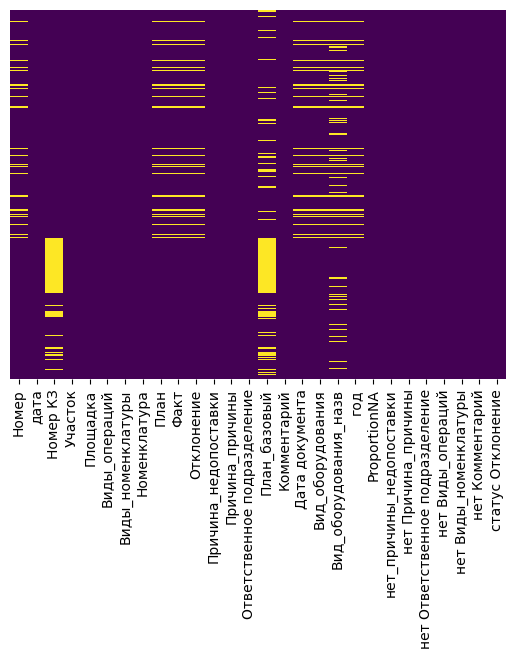

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

<Figure size 640x480 with 0 Axes>

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
#анализ наполненности дата фрейма
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

In [48]:
#создаем серию группированную по величине продаж
sal_jp = df.groupby('Участок')['Факт'].mean()
sal_jp

Участок
Участок производства масла 1      1293.142177
Участок производства масла 2      2547.972173
Участок производства сметаны 1     455.523617
Участок производства сметаны 2    1400.572151
Участок производства сыра 1       1695.890866
Участок производства творога 2    1750.752115
Участок промышленных ТПИ 1                NaN
Экспериментальный цех                     NaN
Name: Факт, dtype: float64

In [179]:
#создаем функцию для сохранения графиков
import os
import matplotlib.pyplot as plt
from datetime import datetime
from functools import wraps
def advanced_save(block_name="план-факт-кз", plot_name=None, dpi=150, formats=['png']):
    """
    Усовершенствованная функция сохранения с поддержкой multiple formats
    
    Parameters:
    block_name (str): Название блока/проекта
    plot_name (str): Название графика
    dpi (int): Качество сохранения
    formats (list): Список форматов для сохранения ['png', 'pdf', 'svg']
    """
    base_dir = r"C:\Users\user0907"
    current_date = datetime.now().strftime('%Y-%m-%d')
    output_path = os.path.join(base_dir, 'SQL_Import', current_date, block_name)
    os.makedirs(output_path, exist_ok=True)
    
    if plot_name is None:
        plot_name = f"plot_{datetime.now().strftime('%H%M%S')}"
    else:
        plot_name = "".join(c if c.isalnum() or c in ('-', '_') else '_' for c in plot_name)
    
    saved_files = []
    for fmt in formats:
        filename = os.path.join(output_path, f"{plot_name}.{fmt}")
        plt.savefig(filename, dpi=dpi, bbox_inches='tight', facecolor='white', format=fmt)
        saved_files.append(filename)
        print(f"Сохранен {fmt.upper()}: {filename}")
    
    return saved_files

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Распределение_объема.png


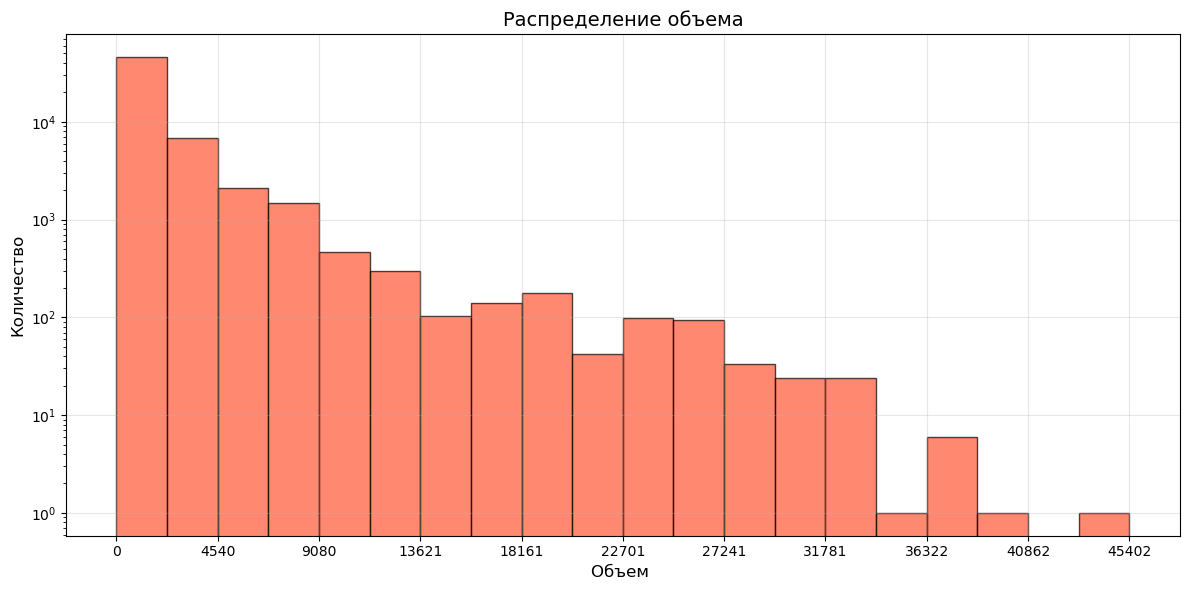

In [223]:
plt.figure(figsize=(12, 6))
plt.hist(df['План'], bins=20, alpha=0.7, color='#FF5733', edgecolor='black', log=True)
x = 'Распределение объема'
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('Объем ', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(True, alpha=0.3)

#вычисление осси х
bind_x = df['План'].max() / 10 #шаг для меток оси х
x_range = [x * bind_x for x in range(11)]
plt.xticks(x_range)

plt.tight_layout()
advanced_save(block_name="план-факт-кз",  plot_name=x)
plt.show()


In [46]:
#очистка
df = df.dropna(subset=['Площадка'])

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

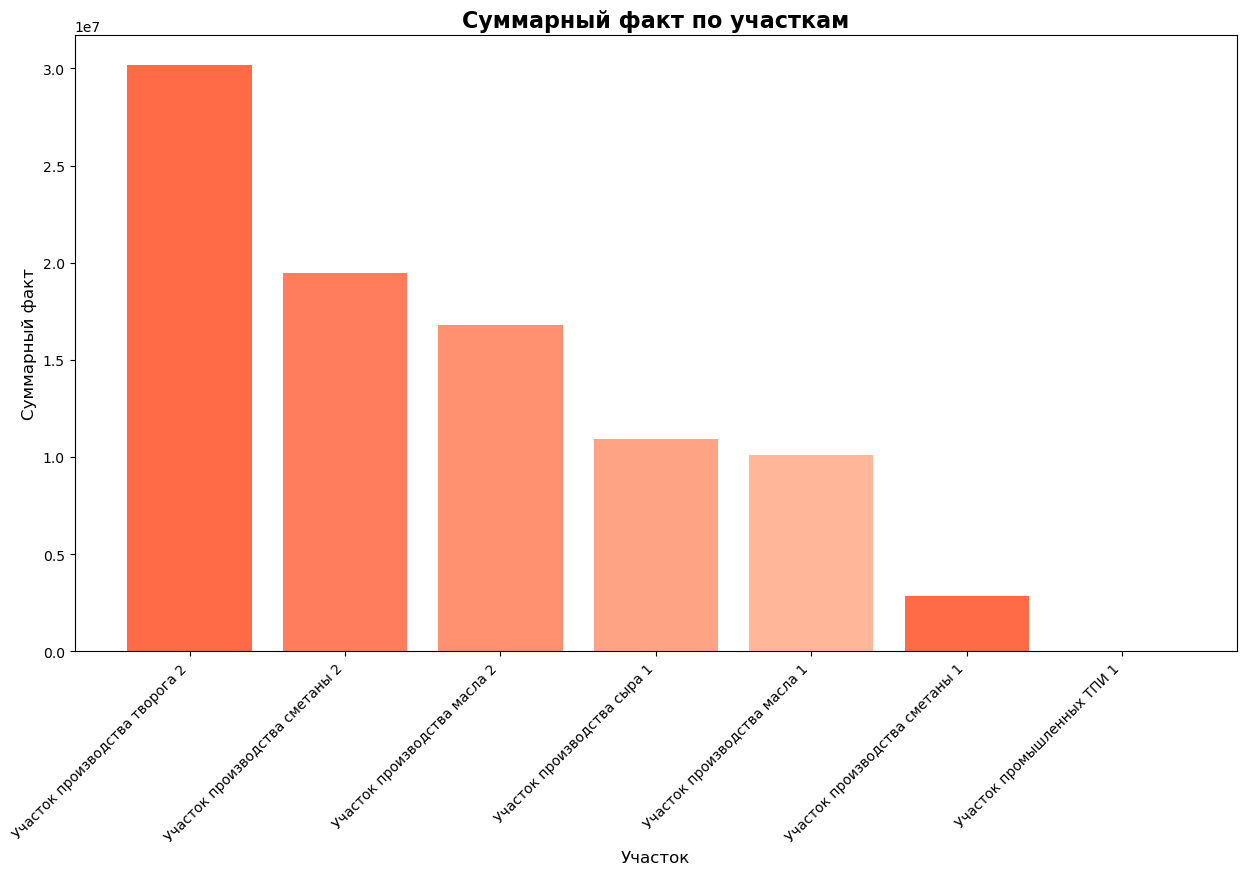

In [190]:
#получаем требуемую таблицу
#in_bar = df[df['Площадка'] == 'МПК']
# Группируем данные по участкам и суммируем фактические значения
grouped_data = df.groupby('Участок')['Факт'].sum().sort_values(ascending=False)
# Строим график
plt.figure(figsize=(15, 8))
bars = plt.bar(grouped_data.index, grouped_data.values, 
               color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699'])

plt.title('Суммарный факт по участкам', fontsize=16, fontweight='bold')
plt.xlabel('Участок', fontsize=12)
plt.ylabel('Суммарный факт', fontsize=12)
plt.xticks(rotation=45, ha='right')
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

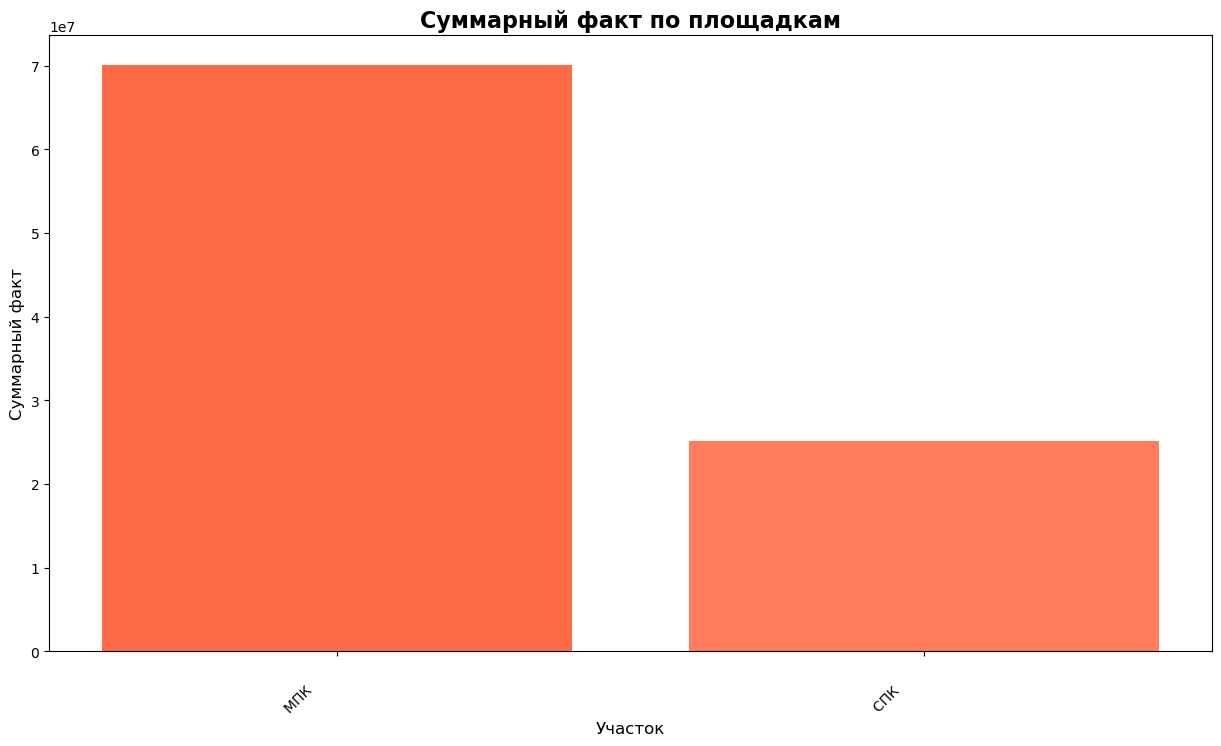

In [189]:
#получаем требуемую таблицу
#in_bar = df[df['Площадка'] == 'МПК']
# Группируем данные по участкам и суммируем фактические значения
grouped_data = df.groupby('Площадка')['План'].sum().sort_values(ascending=False)
# Строим график
plt.figure(figsize=(15, 8))
bars = plt.bar(grouped_data.index, grouped_data.values, 
               color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699'])

plt.title('Суммарный факт по площадкам', fontsize=16, fontweight='bold')
plt.xlabel('Участок', fontsize=12)
plt.ylabel('Суммарный факт', fontsize=12)
plt.xticks(rotation=45, ha='right')
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

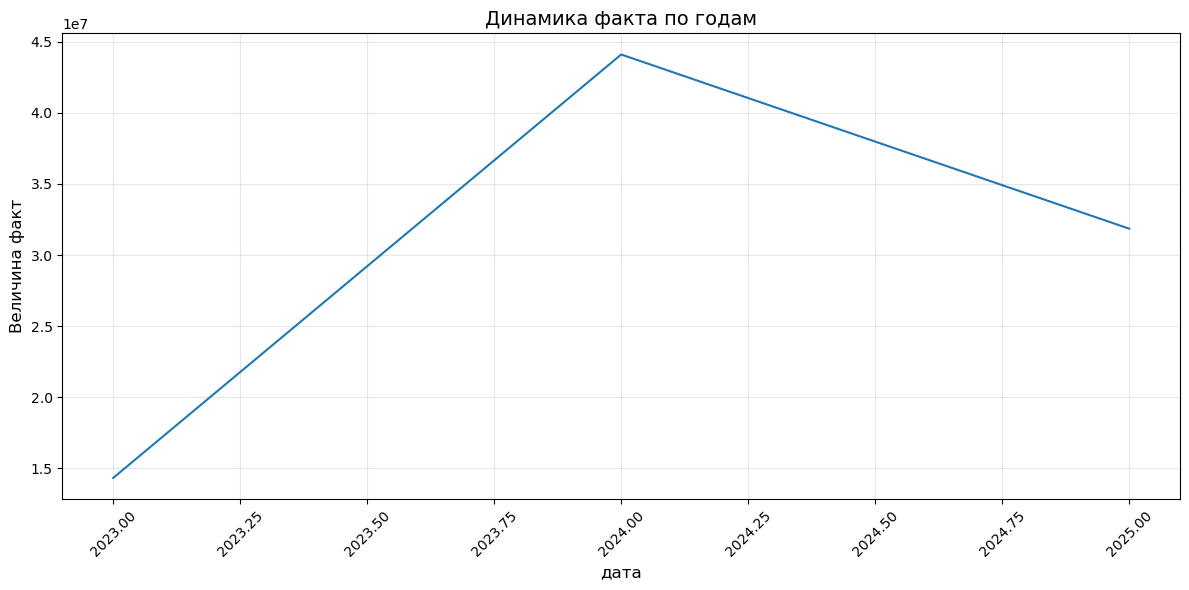

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

<Figure size 640x480 with 0 Axes>

In [188]:
#переводим даты в формат datetime и добавляем колонку с выборкой только года от даты
df['Дата документа'] = pd.to_datetime(df['Дата документа'])
df['год'] = df['Дата документа'].dt.year
#создаем серию группированную по глобальным продажам
series3 = df.groupby('год')['Факт'].sum()
#сортировка по возрастанию по году
series3 = series3.sort_index()
#series3
#создание полотна для графика
plt.figure(figsize=(12, 6))
#нанесение значений серии на график
plt.plot(series3)
#Настройка графика
plt.title('Динамика факта по годам', fontsize=14)
plt.xlabel('дата', fontsize=12)
plt.ylabel('Величина факт', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

#показать график
plt.show()
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Зависимоть_Факта_от_плана.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Зависимоть_Факта_от_плана.png']

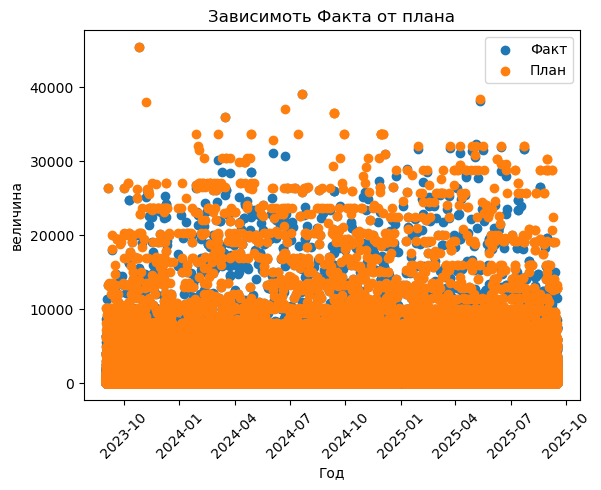

In [213]:
#добавляем столбец с пропорциями: если продажи в NA больше половины от общего количества, то 1 (зависимость есть), иначе 0
df['ProportionNA'] = (df['Факт'] >= df['План']).astype(int)

#точечный график
x = 'Зависимоть Факта от плана'
plt.title("Зависимоть ")
plt.ylabel('млн. копий')
plt.xlabel('Год')

#добавление легенды
df_0 = df[df['ProportionNA']== 0]
plt.scatter(df['Дата документа'], df['Факт'], label=f"Факт")
df_1 = df[df['ProportionNA']== 1]
plt.scatter(df['Дата документа'], df['План'], label=f"План")

plt.title(x)
plt.ylabel('величина')
plt.xlabel('Год')
plt.legend()
plt.xticks(rotation=45)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

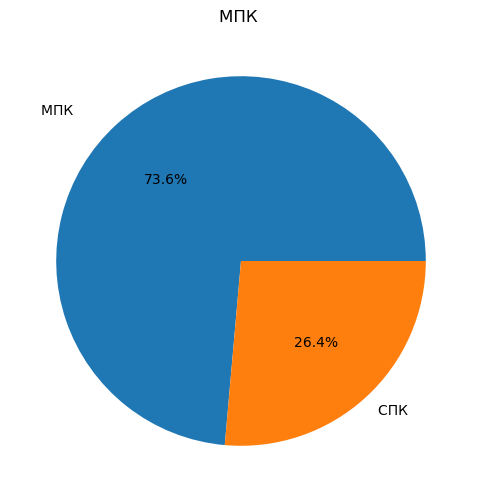

In [186]:
#получаем требуемую таблицу


#группируем по платформе и суммируем продажи
sales_by_platform = df.groupby('Площадка')['Факт'].sum()
#настройка графика
plt.figure(figsize=(20, 6))
plt.pie(sales_by_platform, labels = sales_by_platform.index, autopct = '%1.1f%%')
plt.title("МПК ")
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

AttributeError: 'tuple' object has no attribute 'to_excel'

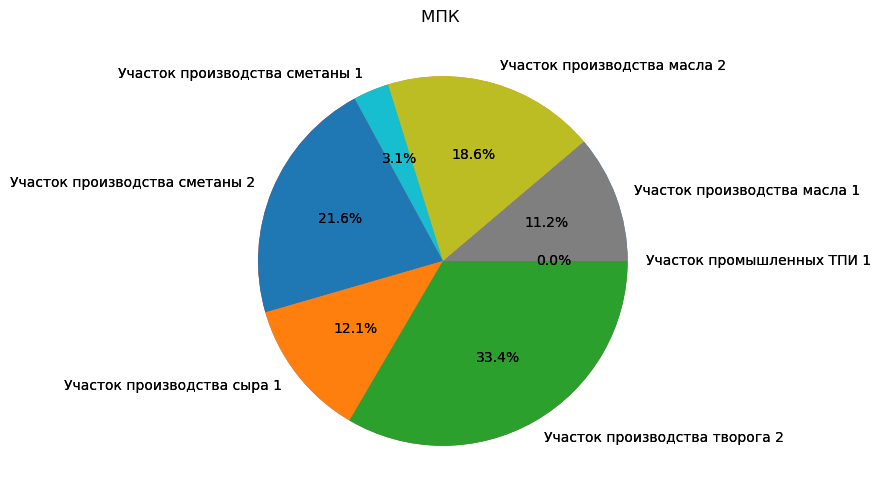

In [185]:
#группируем по платформе и суммируем продажи
sales_by_platform = df.groupby('Участок')['Факт'].sum()
#настройка графика
plt.figure(figsize=(20, 6))
plt.pie(sales_by_platform, labels = sales_by_platform.index, autopct = '%1.1f%%')
plt.title("МПК ")
df8 = plt.pie(sales_by_platform, labels = sales_by_platform.index, autopct = '%1.1f%%')
df8.to_excel('7utra.xlsx', sheet_name = '7utraSheet', index = False)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

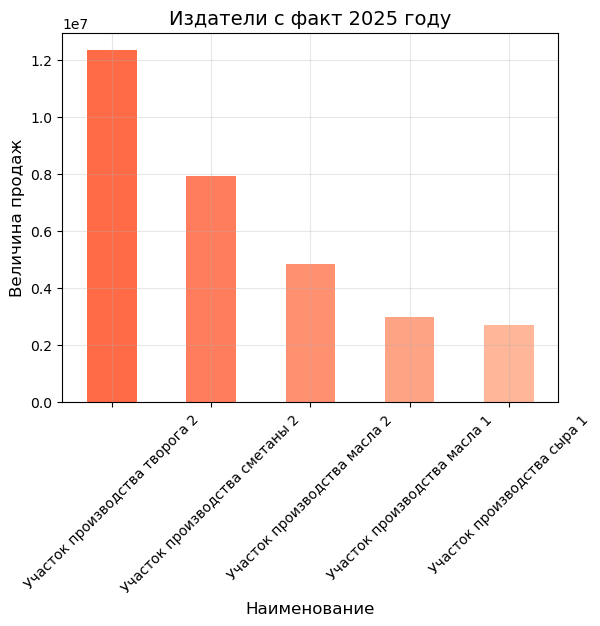

In [184]:
#строим серию с цепочкой: выборкой по 2013 году, группировкой по издателям и сумме продаж,
#сортировкой по убыванию, обрезаем первые пять
df_2025 = (df[df['год'] == 2025].groupby('Участок')['Факт'].sum().sort_values(ascending=False).head(5))

#строем гистограмму
df_2025.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699'])
#настройка графика
plt.title('Издатели с факт 2025 году', fontsize=14)
plt.xlabel('Наименование', fontsize=12)
plt.ylabel('Величина продаж', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

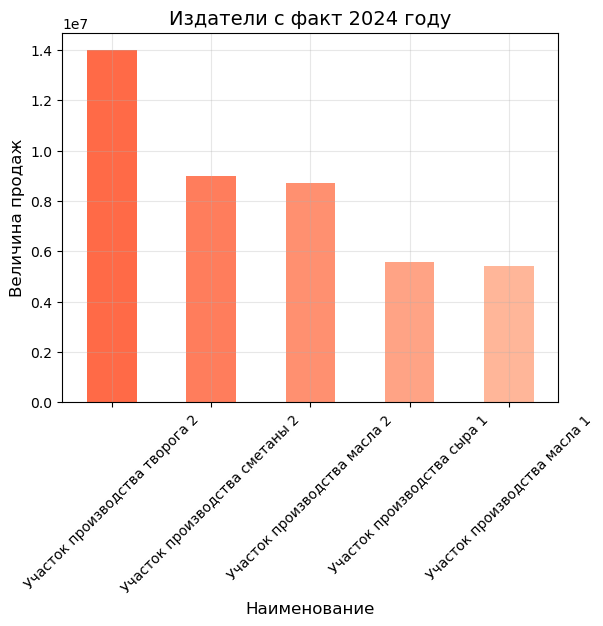

In [183]:
#строим серию с цепочкой: выборкой по 2013 году, группировкой по издателям и сумме продаж,
#сортировкой по убыванию, обрезаем первые пять
df_2024 = (df[df['год'] == 2024].groupby('Участок')['Факт'].sum().sort_values(ascending=False).head(5))

#строем гистограмму
df_2024.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699'])
#настройка графика
plt.title('Издатели с факт 2024 году', fontsize=14)
plt.xlabel('Наименование', fontsize=12)
plt.ylabel('Величина продаж', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

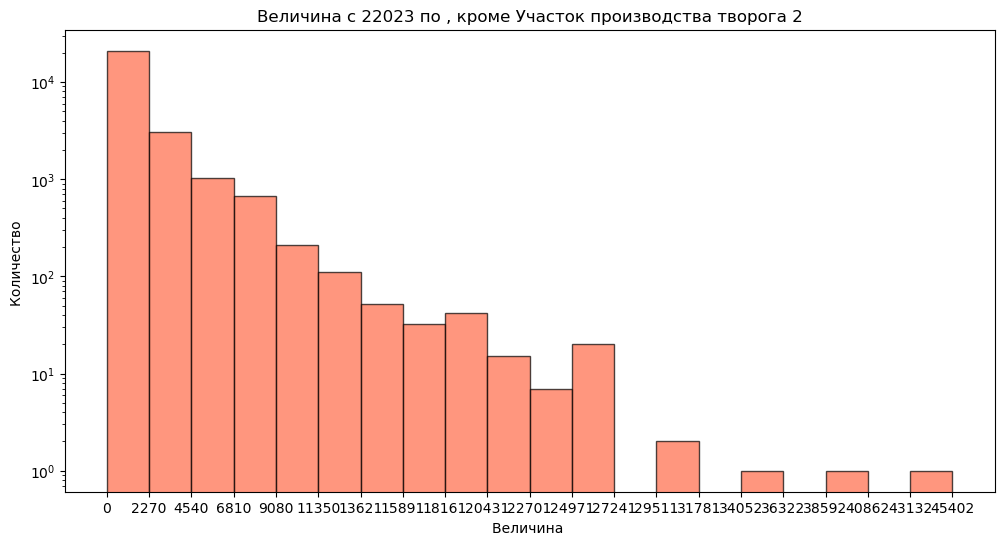

In [182]:
#фильтруем данные: 2000-2015 годы, кроме Nintendo
filtered_data = df[(df['год'] >= 2023) & (df['год'] < 2025) & (df['Участок'] != 'Участок производства творога 2')]

#берем только столбец с продажами для гистограммы
sales_values = filtered_data['Факт']

#строем гистограмму
plt.figure(figsize=(12, 6))
plt.hist(sales_values, bins=20, alpha=0.7, color='#FF6A47', edgecolor='black', log=True)

#построение отсечек на оси х
max_sales = sales_values.max()
bind_x = max_sales / 20
x_range = [i * bind_x for i in range(21)]
#подписываем график
plt.title("Величина с 22023 по , кроме Участок производства творога 2")
plt.xlabel("Величина ")
plt.ylabel("Количество ")
plt.xticks(x_range)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Динамика_количества_записей_по_участку_производства_творога_2.png


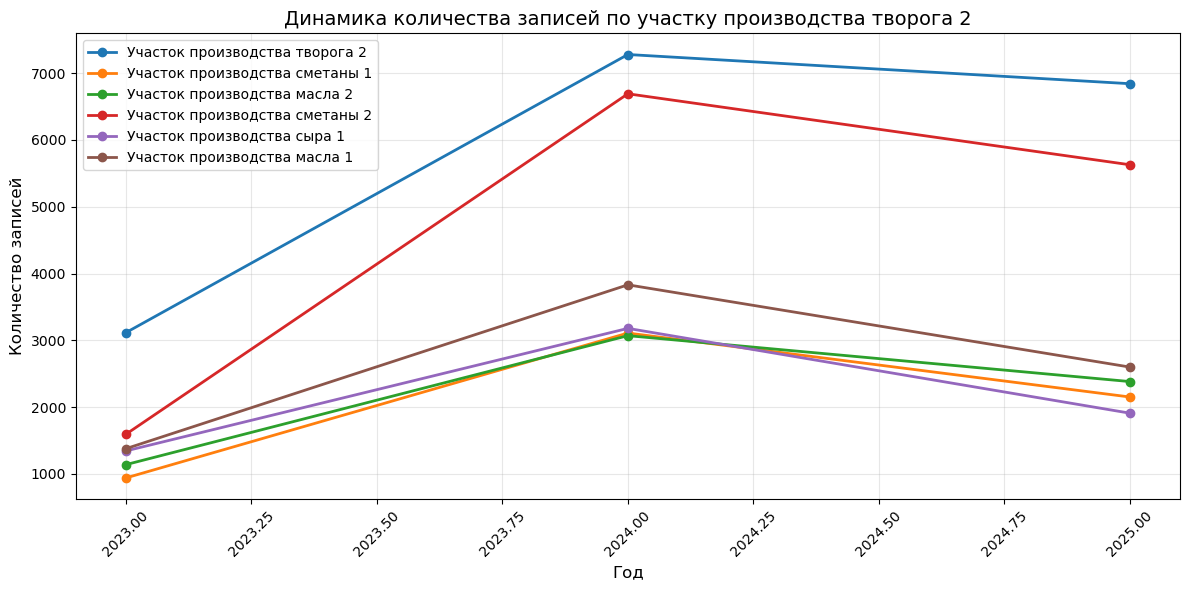

In [220]:
# Подсчитываем количество записей по годам для указанного участка
pr_list = ['Участок производства творога 2', 'Участок производства сметаны 1', 'Участок производства масла 2', 'Участок производства сметаны 2',
          'Участок производства сыра 1', 'Участок производства масла 1']
x = 'Динамика количества записей по участку производства творога 2'
# Создание графика
plt.figure(figsize=(12, 6))  # Уменьшили размер для экономии памяти
for i in pr_list:
    df_Action = (df[df['Участок'] == i]
             .groupby('год')
             .size()  # Используем size() вместо sum() для подсчета количества
             .sort_index())

    
    plt.plot(df_Action.index, df_Action.values, marker='o', linewidth=2, label = i)
plt.title('Динамика количества записей по участку производства творога 2', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
advanced_save(block_name="план-факт-кз", plot_name=x)
plt.show()


Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\показатели_площадок.png


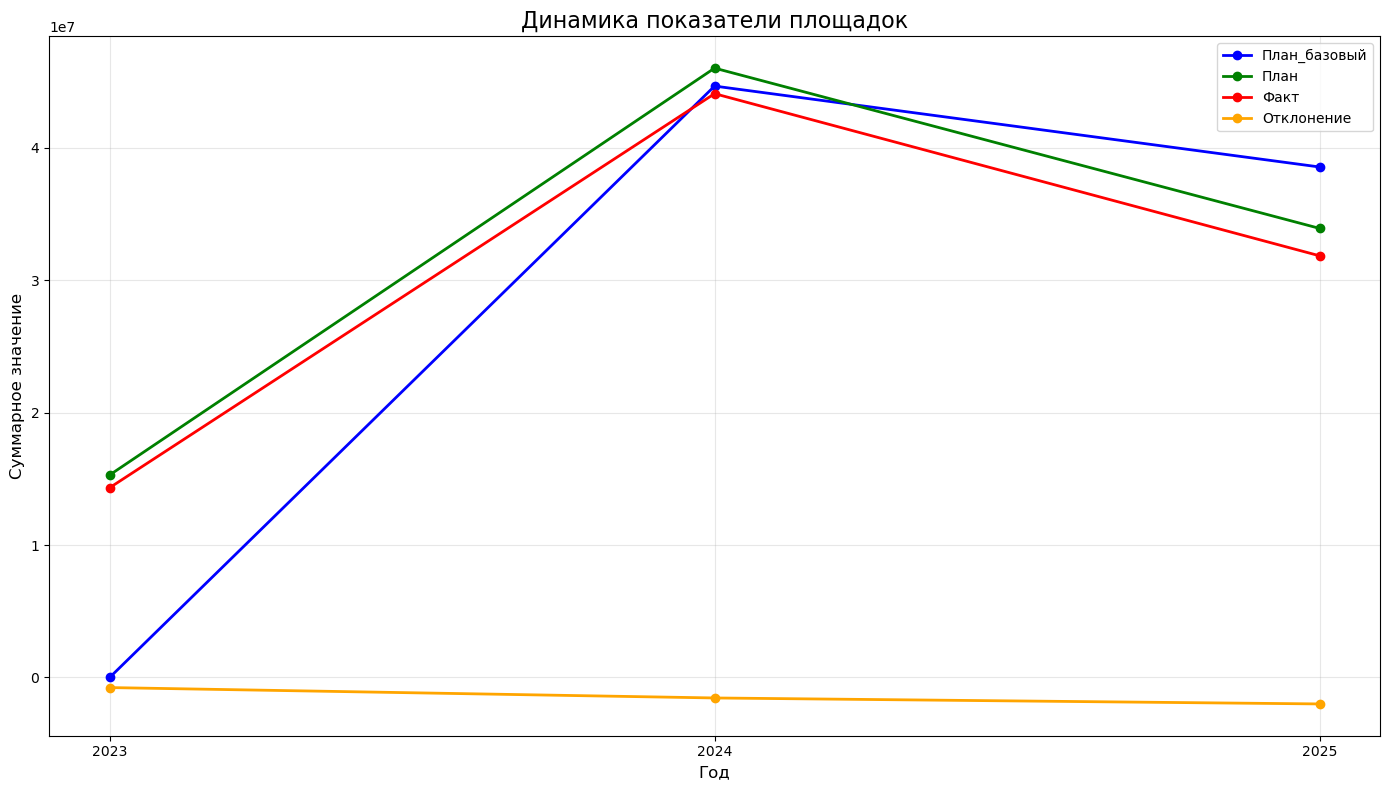

In [221]:
# Создаем фигуру
plt.figure(figsize=(14, 8))
# Создаем словарь цветов для показателей
colors = {'План_базовый': 'blue', 'План': 'green', 'Факт': 'red', 'Отклонение': 'orange'}
x = 'показатели площадок'
# Для каждого показателя строим линию
for column in ['План_базовый', 'План', 'Факт', 'Отклонение']:
    # Группируем по году и суммируем показатель
    yearly_data = df.groupby('год')[column].sum()
    plt.plot(yearly_data.index, yearly_data.values, 
             label=column, color=colors.get(column, 'black'), linewidth=2, marker='o')
    #advanced_save(block_name="план-факт-кз", plot_name=x)
plt.title(f'Динамика {x}', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное значение', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(yearly_data.index)  # Чтобы все года отображались на оси X
plt.tight_layout()
advanced_save(block_name="план-факт-кз", plot_name=x)
plt.show()
#advanced_save(block_name="план-факт-кз", plot_name=x)

In [245]:
df_mpk = df[df['Площадка'] == 'МПК       '].groupby('год')['Факт'].sum().sort_index()
df_mpk


год
2023.0     9569271.34
2024.0    31732508.28
2025.0    25150267.82
Name: Факт, dtype: float64

In [270]:
import pymorphy2

In [268]:
!pip install pymorphy2

  DEPRECATION: Building 'docopt' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'docopt'. Discussion can be found at https://github.com/pypa/pip/issues/6334



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 5.3 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.2 MB 5.3 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 5.3 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 5.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 5.1 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 4.9 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 5.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.2 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.w

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-19\план-факт-кз\показатель_факт_по_двум_площадкам.png


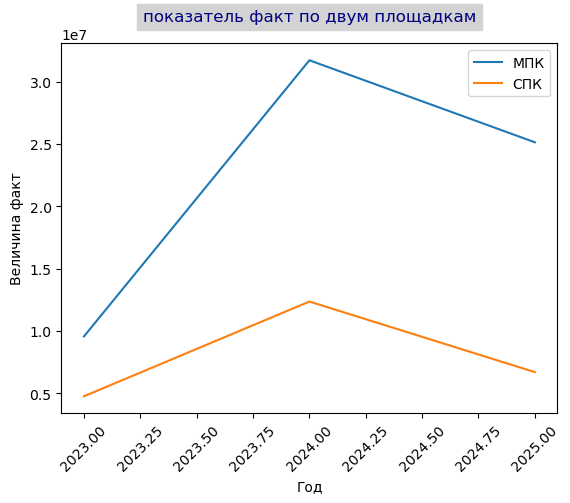

In [250]:
#строим серию с цепочкой: выборкой по производителю "Activision", группировкой по годам и сумме продаж в разных регионах,
#сортирировкой по годам (по возрастанию)
df_ActivisionNA = (df[df['Площадка'] == 'МПК       '].groupby('год')['Факт'].sum().sort_index())
df_ActivisionEU = (df[df['Площадка'] == 'СПК       '].groupby('год')['Факт'].sum().sort_index())
x = 'показатель факт по двум площадкам'
#создаем объекты для построения графика
fig, ax = plt.subplots()
#наносим значеиня каждой серии с помощтю метода plot объекта класса ax и добавляем Лейбл
ax.plot(df_ActivisionNA.index, df_ActivisionNA.values, label = 'МПК')
ax.plot(df_ActivisionEU.index, df_ActivisionEU.values, label = 'СПК')

#добавляем методы объектов для подписи графиков
ax.set_title(x, pad = 16, color = 'navy', backgroundcolor = 'lightgray')
ax.set_xlabel('Год')
ax.set_ylabel('Величина факт')
#переопределяем ось х
#ax.set_xticks(df_ActivisionALL.index[::5])
#выводим легенду
ax.legend()
plt.xticks(rotation=45)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)
plt.show()

In [242]:
#уникальные значения в колонке
df_mpk_u = df['Площадка'].unique()
df_mpk_u

array(['СПК       ', 'МПК       '], dtype=object)

In [251]:
#уникальные значения в колонке
df_u = df['Участок'].unique()
df_u

array(['Участок производства сметаны 1', 'Участок производства сметаны 2',
       'Участок производства творога 2', 'Участок производства масла 1',
       'Участок производства масла 2', 'Участок производства сыра 1',
       'Участок промышленных ТПИ 1'], dtype=object)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-19\план-факт-кз\показатель_факт_по_всем_участкам.png


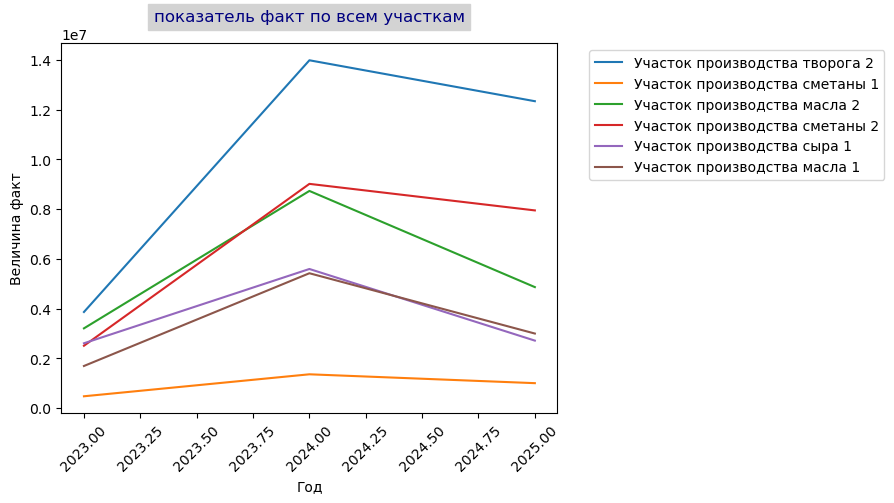

In [258]:
#строим серию с цепочкой: выборкой по производителю "Activision", группировкой по годам и сумме продаж в разных регионах,
#сортирировкой по годам (по возрастанию)
pr_list = ['Участок производства творога 2', 'Участок производства сметаны 1', 'Участок производства масла 2', 'Участок производства сметаны 2',
          'Участок производства сыра 1', 'Участок производства масла 1']
x = 'показатель факт по всем участкам'
#создаем объекты для построения графика
fig, ax = plt.subplots()
for i in pr_list:    
    df_ActivisionNA = (df[df['Участок'] == i].groupby('год')['Факт'].sum().sort_index())
    ax.plot(df_ActivisionNA.index, df_ActivisionNA.values, label = i)




#добавляем методы объектов для подписи графиков
ax.set_title(x, pad = 16, color = 'navy', backgroundcolor = 'lightgray')
ax.set_xlabel('Год')
ax.set_ylabel('Величина факт')
#переопределяем ось х
#ax.set_xticks(df_ActivisionALL.index[::5])
#выводим легенду
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)
plt.show()

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-19\план-факт-кз\количество_показаний__Ответственное_подразделение.png


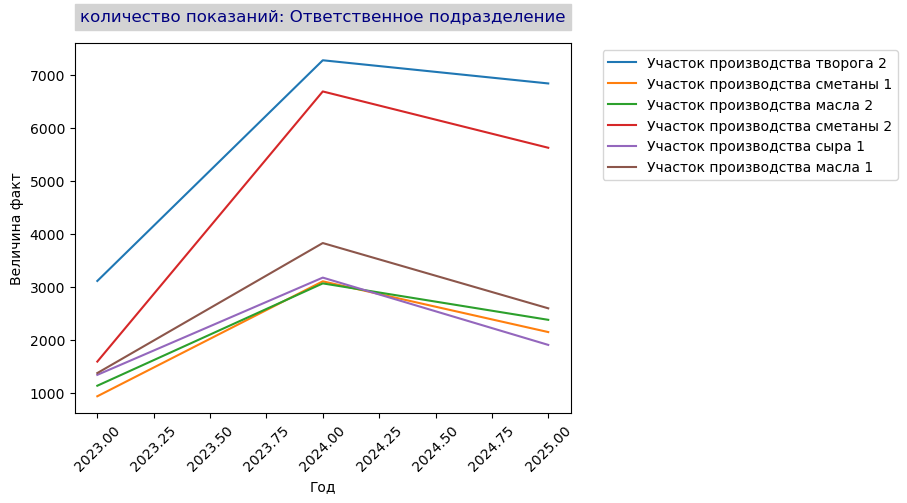

In [260]:
#строим серию с цепочкой: выборкой по производителю "Activision", группировкой по годам и сумме продаж в разных регионах,
#сортирировкой по годам (по возрастанию)
pr_list = ['Участок производства творога 2', 'Участок производства сметаны 1', 'Участок производства масла 2', 'Участок производства сметаны 2',
          'Участок производства сыра 1', 'Участок производства масла 1']
x = 'количество показаний: Ответственное подразделение'
#создаем объекты для построения графика
fig, ax = plt.subplots()
for i in pr_list:    
    df_ActivisionNA = (df[df['Участок'] == i].groupby('год')['Ответственное подразделение'].size().sort_index())
    ax.plot(df_ActivisionNA.index, df_ActivisionNA.values, label = i)


#добавляем методы объектов для подписи графиков
ax.set_title(x, pad = 16, color = 'navy', backgroundcolor = 'lightgray')
ax.set_xlabel('Год')
ax.set_ylabel('Величина факт')
#переопределяем ось х
#ax.set_xticks(df_ActivisionALL.index[::5])
#выводим легенду
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)
plt.show()

In [261]:
df.head()

,Номер,дата,Номер КЗ,Участок,Площадка,Виды_операций,Виды_номенклатуры,Номенклатура,План,Факт,...,Вид_оборудования_назв,год,ProportionNA,нет_причины_недопоставки,нет Причина_причины,нет Ответственное подразделение,нет Виды_операций,нет Виды_номенклатуры,нет Комментарий,статус Отклонение
1,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,Десерт ЙLine.10%.банан.350г.ст.12шт,289.8,289.8,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
2,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.2,5%.с киви.двухсл.350г.ст.12шт",848.4,848.4,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
3,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с черникой.двухсл.350г.ст.12шт",726.6,726.6,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
4,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с вишн.двухсл.350г.ст.12шт",189.0,189.0,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
5,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с киви.двухсл.350г.ст.12шт",747.6,806.4,...,Фасовочный автомат «АДНК»,2024.0,1,заполнено поле,заполнено поле,заполнено поле,заполнено поле,заполнено поле,не заполнено поле,больше 0


Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-19\план-факт-кз\количество_показаний__Виды_операций.png


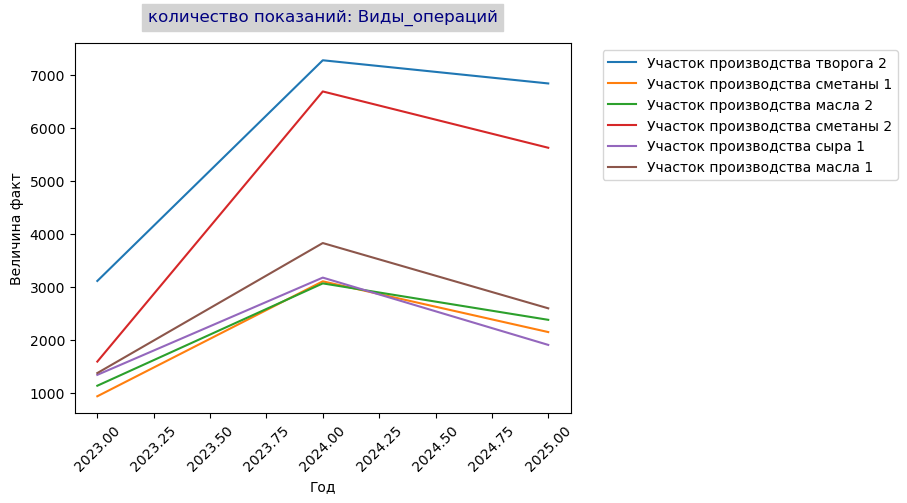

In [263]:
#строим серию с цепочкой: выборкой по производителю "Activision", группировкой по годам и сумме продаж в разных регионах,
#сортирировкой по годам (по возрастанию)
pr_list = ['Участок производства творога 2', 'Участок производства сметаны 1', 'Участок производства масла 2', 'Участок производства сметаны 2',
          'Участок производства сыра 1', 'Участок производства масла 1']
x = 'количество показаний: Виды_операций'
#создаем объекты для построения графика
fig, ax = plt.subplots()
for i in pr_list:    
    df_ActivisionNA = (df[df['Участок'] == i].groupby('год')['Виды_операций'].size().sort_index())
    ax.plot(df_ActivisionNA.index, df_ActivisionNA.values, label = i)


#добавляем методы объектов для подписи графиков
ax.set_title(x, pad = 16, color = 'navy', backgroundcolor = 'lightgray')
ax.set_xlabel('Год')
ax.set_ylabel('Величина факт')
#переопределяем ось х
#ax.set_xticks(df_ActivisionALL.index[::5])
#выводим легенду
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
advanced_save(block_name="план-факт-кз", 
             plot_name=x)
plt.show()

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-19\план-факт-кз\показатели_по_площадке_МПК_по_годам.png


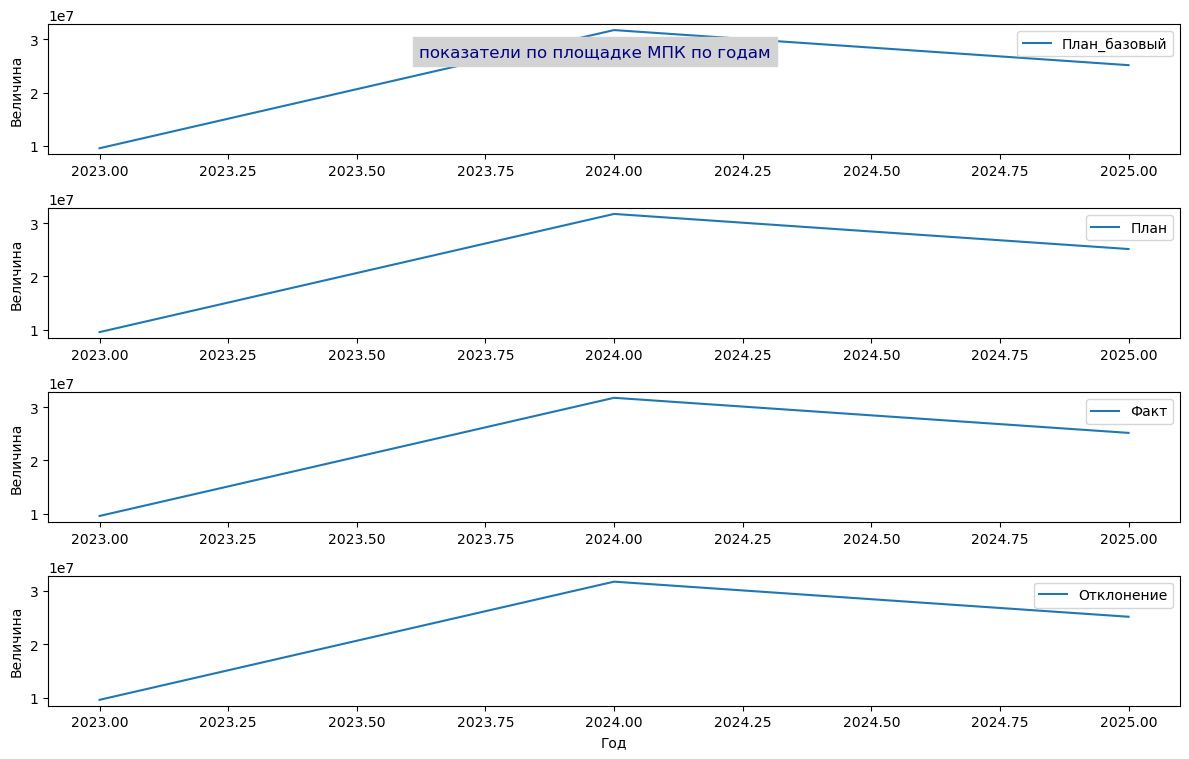

In [248]:
#создаем объекты для построения графика, задаем атрибуты
fig, axs = plt.subplots(nrows = 4, sharey = True, figsize=(12, 8))
list_series = ['План_базовый', 'План', 'Факт', 'Отклонение']
x = 'показатели по площадке МПК по годам'
#наносим значеиня каждой серии с помощтю метода plot объекта класса axs
for i, column in enumerate(list_series):
    #добавляем серию в цикл, перебираем по значениям листа list_series
    df_Activision = (df[df['Площадка'] == 'МПК       '].groupby('год')['Факт'].sum().sort_index()) 
    ax = axs[i]
    ax.plot(df_Activision.index, df_Activision.values, label=column)
    ax.legend()
    #добавляем методы объектов для подписи графиков
    if i == len(list_series) - 1:
        ax.set_xlabel('Год') #Только на последнем графике подпись оси X
    ax.set_ylabel('Величина')
fig.suptitle(x, color='navy', backgroundcolor='lightgray', y=0.90)     
plt.tight_layout()
advanced_save(block_name="план-факт-кз", 
             plot_name=x)
plt.show()


Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-19\план-факт-кз\показатели_по_площадке_МПК_по_годам_4х4.png


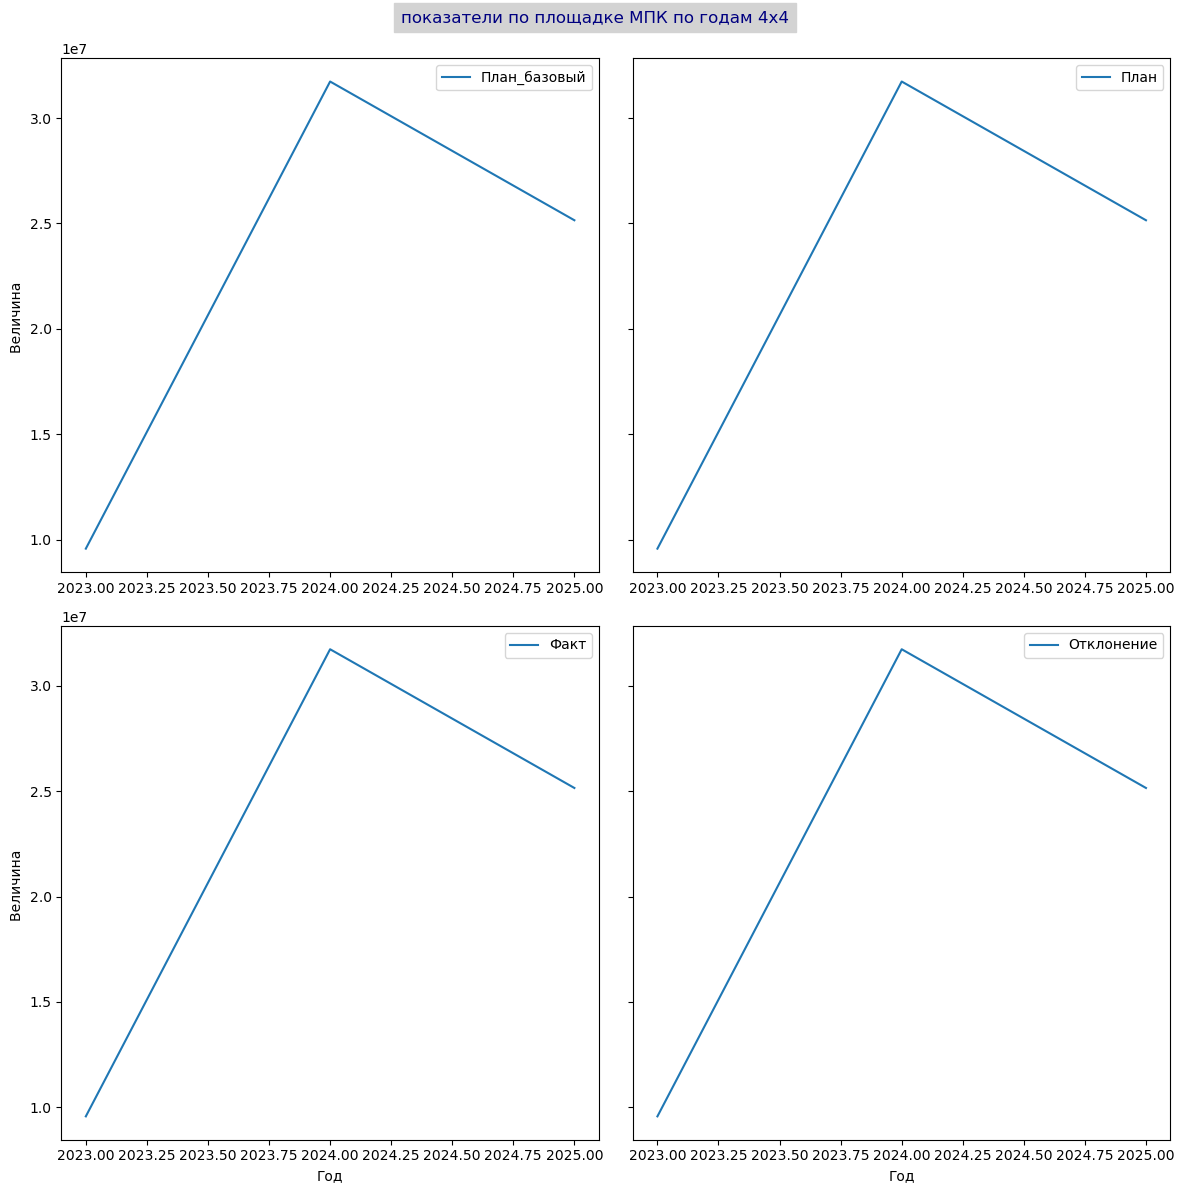

In [264]:
#создаем объекты для построения графика, задаем атрибуты
fig, axs = plt.subplots(ncols = 2, nrows = 2, sharey = True, figsize=(12, 12))
all_series = ['План_базовый', 'План', 'Факт', 'Отклонение']
x = 'показатели по площадке МПК по годам 4х4'
#наносим значеиня каждой серии с помощтю метода plot объекта класса axs
for i, column in enumerate(all_series):
    #определяем позицию на сетке 2x2
    row = i // 2  #0 или 1 для строки
    col = i % 2   #0 или 1 для столбца
    #добавляем серию в цикл, перебираем по значениям листа list_series1 и list_series2
    df_Activision = (df[df['Площадка'] == 'МПК       '].groupby('год')['Факт'].sum().sort_index())    
    #определяем, куда наносить каждую серию
    ax = axs[row][col]
    #наносим с помощью метода plot значения серии и Лейбл
    ax.plot(df_Activision.index, df_Activision.values, label=column)
    ax.legend()
    #добавляем методы объектов для подписи графиков
    if row == 1:
        ax.set_xlabel('Год') 
    if col == 0:
        ax.set_ylabel('Величина ')
fig.suptitle(x, color='navy', backgroundcolor='lightgray', y=0.99)     
plt.tight_layout()
advanced_save(block_name="план-факт-кз", 
             plot_name=x)
plt.show()


Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\дата.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\дата.png']

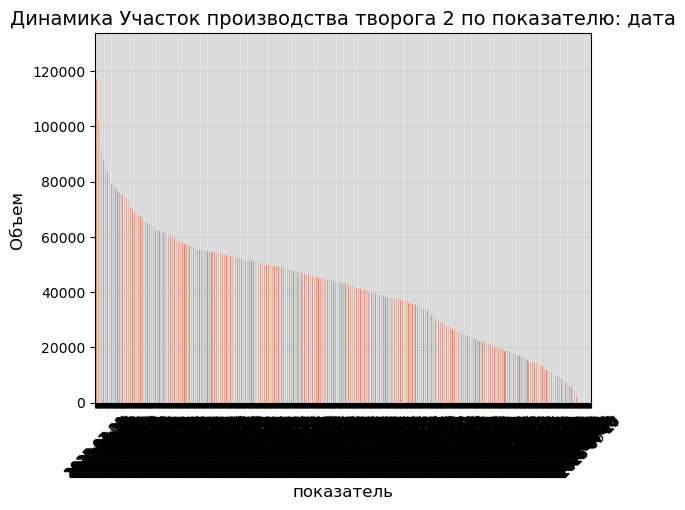

In [180]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('дата')['Факт'].sum().sort_values(ascending=False)
x = 'дата'
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(f'Динамика Участок производства творога 2 по показателю: {x}' , fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\год.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\год.png']

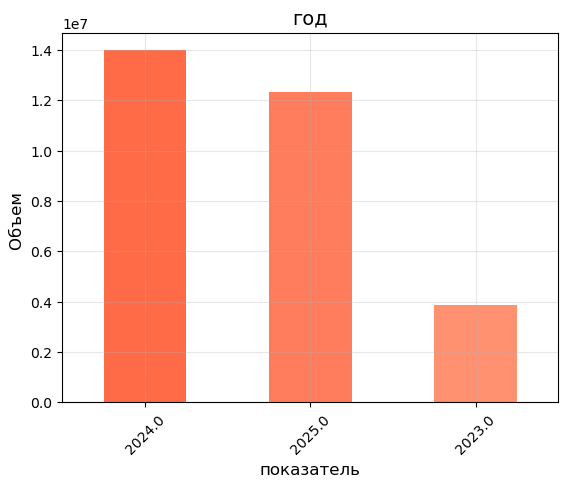

In [222]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('год')['Факт'].sum().sort_values(ascending=False)
x = 'год'
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
#current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
#plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Дата_документа.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Дата_документа.png']

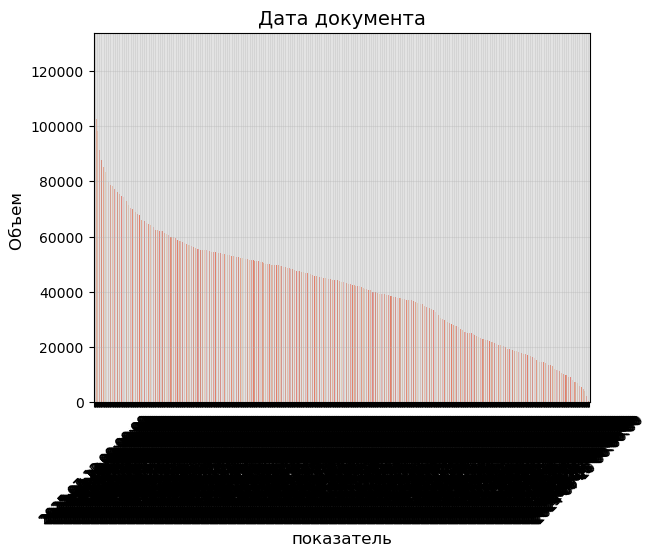

In [194]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Дата документа')['Факт'].sum().sort_values(ascending=False)
x = 'Дата документа'
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Вид_оборудования_назв.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Вид_оборудования_назв.png']

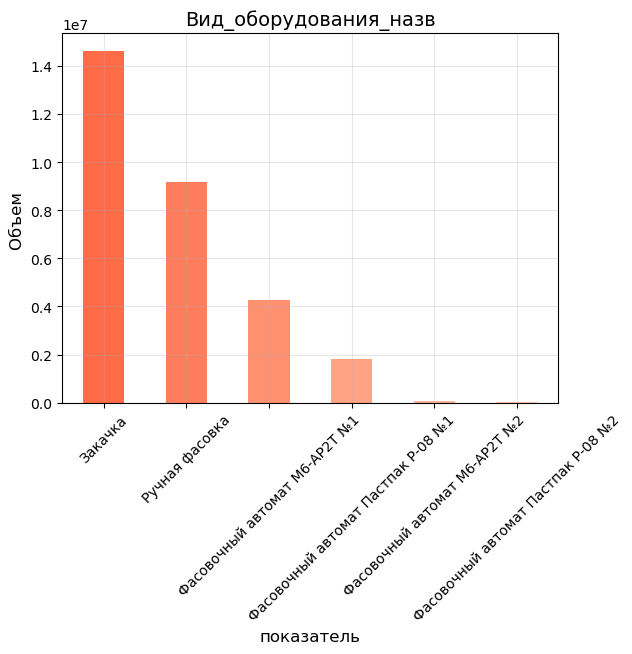

In [195]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Вид_оборудования_назв')['Факт'].sum().sort_values(ascending=False)
x = 'Вид_оборудования_назв'
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Ответственное_подразделение.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Ответственное_подразделение.png']

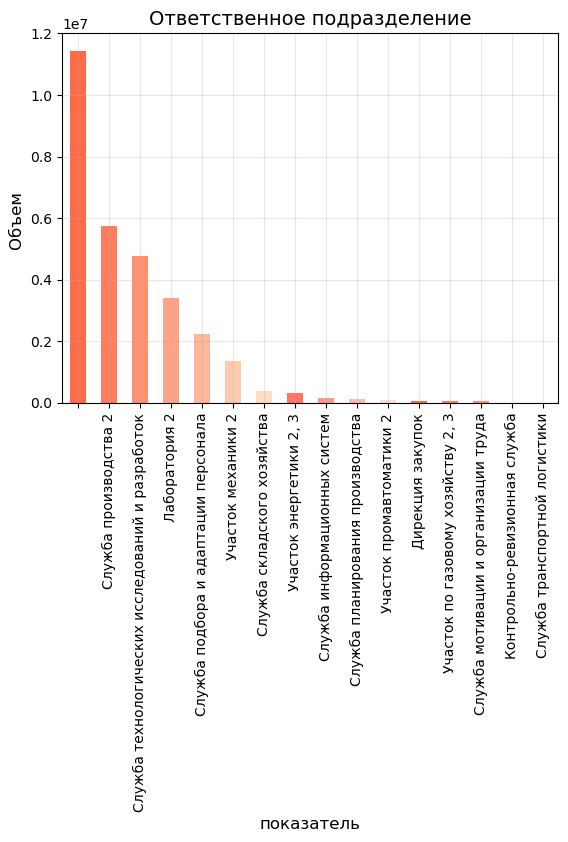

In [196]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Ответственное подразделение')['Факт'].sum().sort_values(ascending=False)
x = 'Ответственное подразделение'
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Причина_причины.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Причина_причины.png']

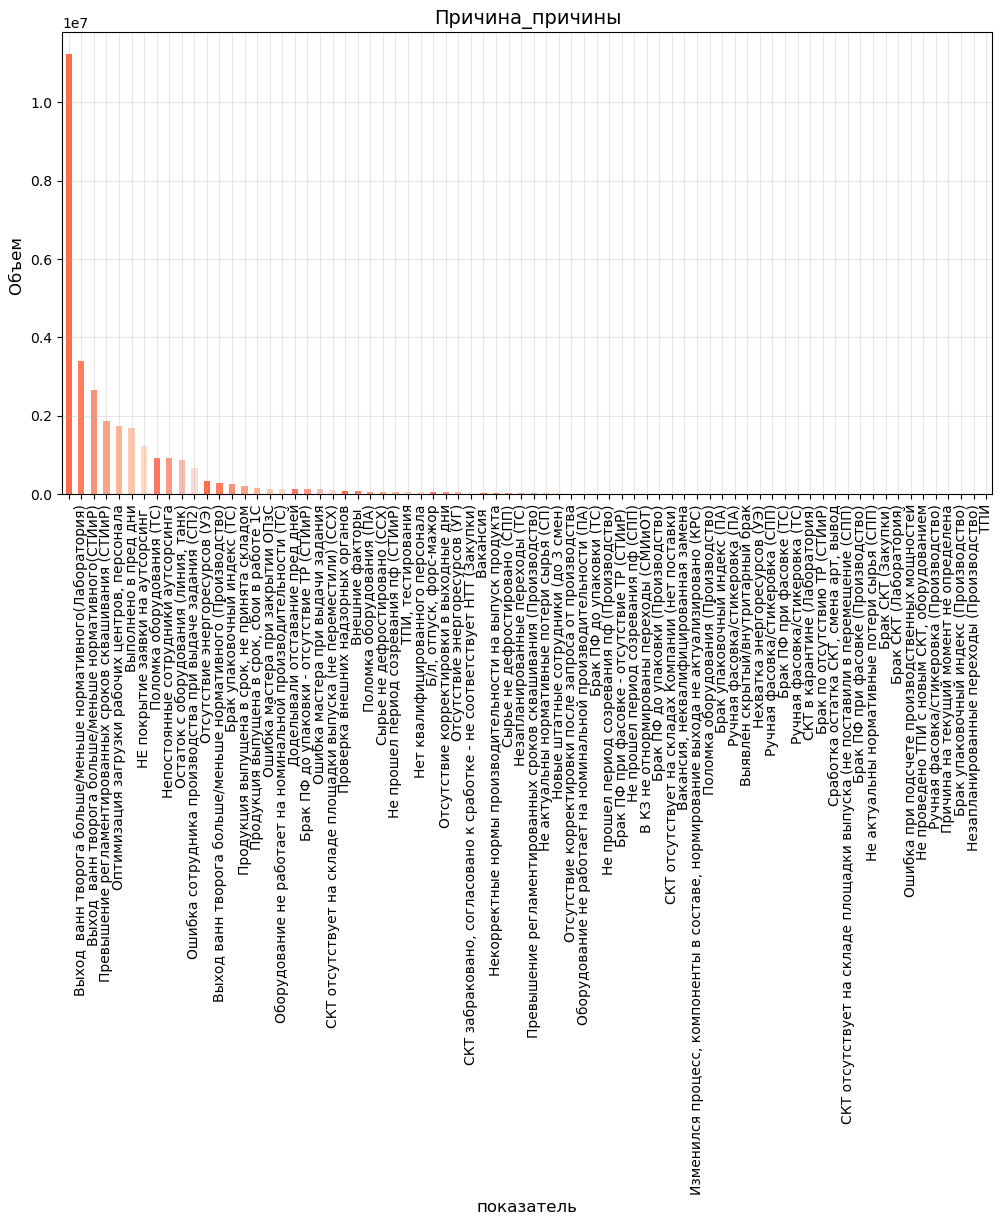

In [197]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
x = 'Причина_причины'
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Причина_причины')['Факт'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))  # Уменьшили размер для экономии памяти
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Причина_недопоставки.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Причина_недопоставки.png']

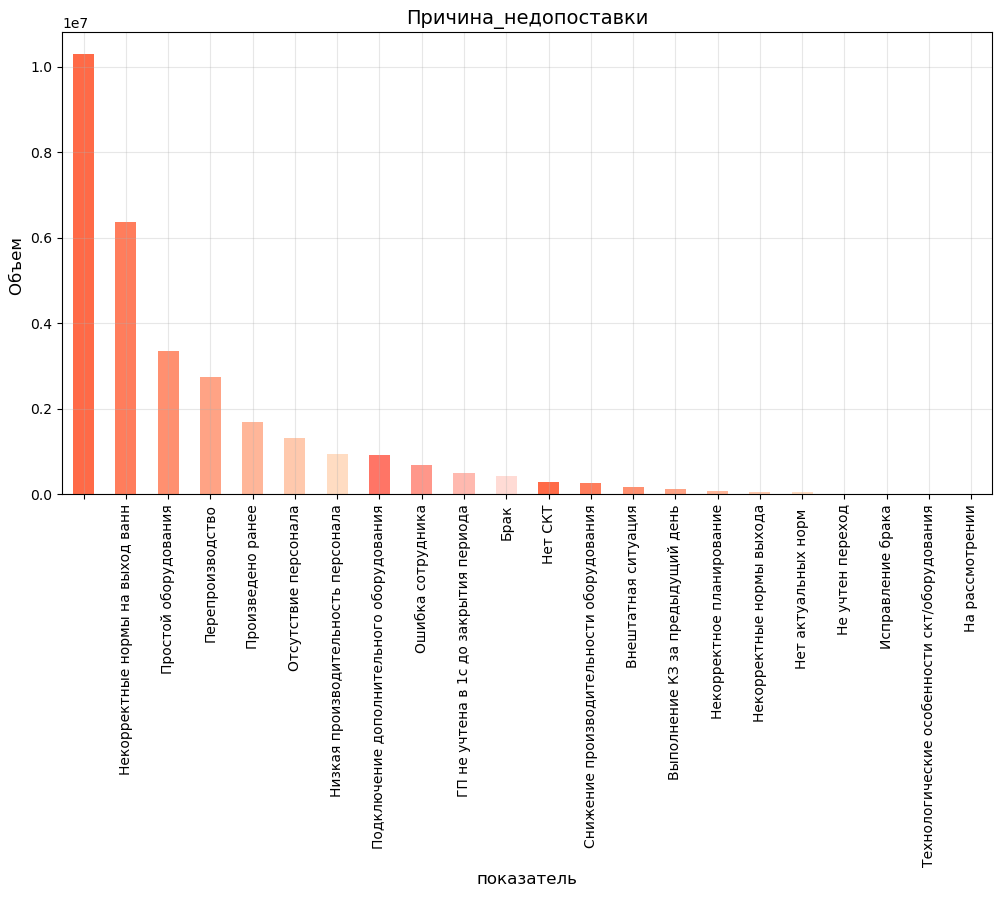

In [198]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
x = 'Причина_недопоставки'
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Причина_недопоставки')['Факт'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))  # Уменьшили размер для экономии памяти
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Номенклатура.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Номенклатура.png']

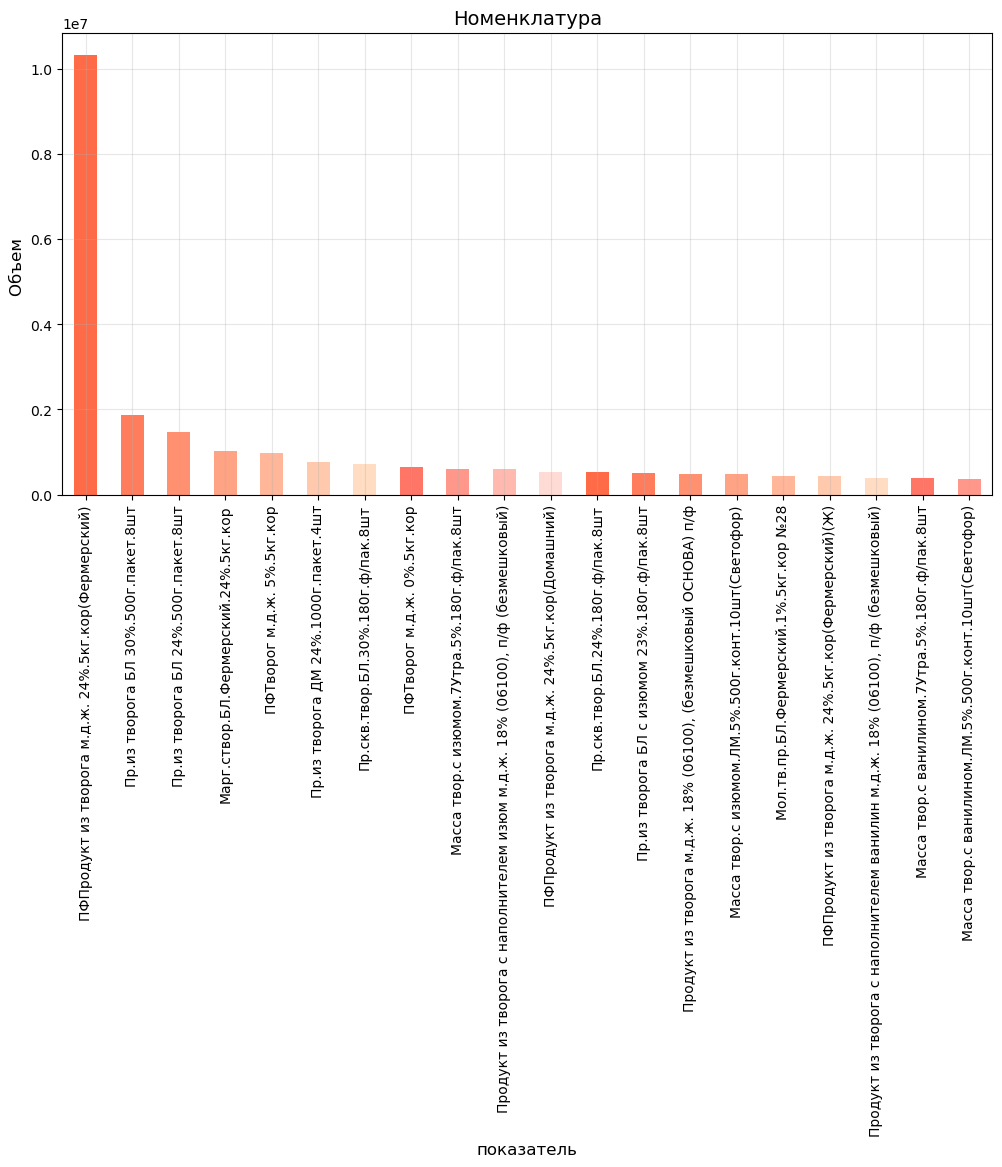

In [199]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
x = 'Номенклатура'
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Номенклатура')['Факт'].sum().sort_values(ascending=False)
df_Microsoft_top20 = df_Microsoft.head(20)
plt.figure(figsize=(12, 6))  # Уменьшили размер для экономии памяти
#строем гистограмму
df_Microsoft_top20.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Виды_операций.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Виды_операций.png']

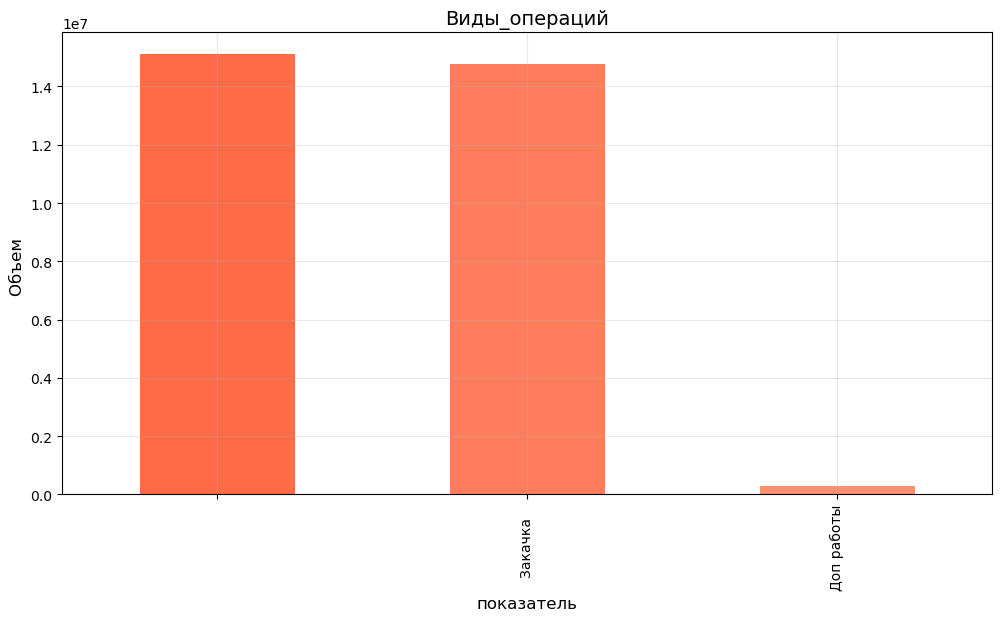

In [200]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
x = 'Виды_операций'
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby('Виды_операций')['Факт'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))  # Уменьшили размер для экономии памяти
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(x, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Виды_операций.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Виды_операций.png']

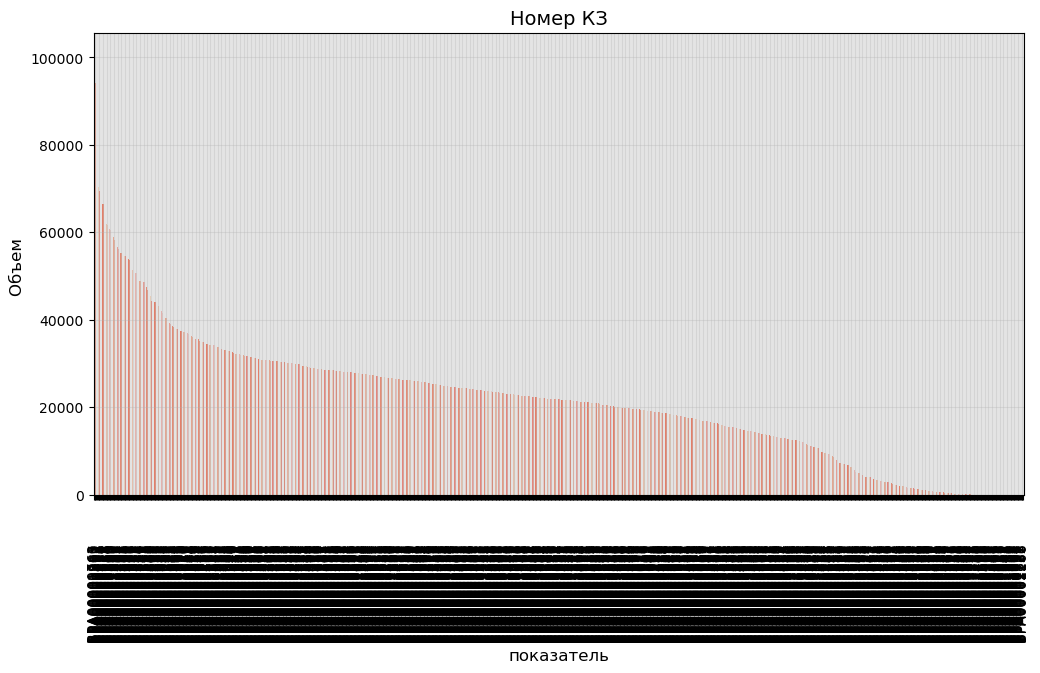

In [201]:
#строим серию с цепочкой: выборкой по издателю 'Microsoft Game Studios', группировкой по жанру и сумме продаж в NA за все время,
#сортировкой по убыванию
X = 'Номер КЗ'
df_Microsoft = (df[df['Участок'] == 'Участок производства творога 2']).groupby(X)['Факт'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))  # Уменьшили размер для экономии памяти
#строем гистограмму
df_Microsoft.plot(kind='bar', color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', '#FFC9AD', '#FFDCC2', '#FF7566' , '#FF978A', '#FFB9AF', '#FFDBD5'])
#настройка графика
plt.title(X, fontsize=14)
plt.xlabel('показатель', fontsize=12)
plt.ylabel('Объем ', fontsize=12)

plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

In [271]:
df

,Номер,дата,Номер КЗ,Участок,Площадка,Виды_операций,Виды_номенклатуры,Номенклатура,План,Факт,...,Вид_оборудования_назв,год,ProportionNA,нет_причины_недопоставки,нет Причина_причины,нет Ответственное подразделение,нет Виды_операций,нет Виды_номенклатуры,нет Комментарий,статус Отклонение
1,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,Десерт ЙLine.10%.банан.350г.ст.12шт,289.8,289.8,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
2,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.2,5%.с киви.двухсл.350г.ст.12шт",848.4,848.4,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
3,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с черникой.двухсл.350г.ст.12шт",726.6,726.6,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
4,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с вишн.двухсл.350г.ст.12шт",189.0,189.0,...,Фасовочный автомат «АДНК»,2024.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
5,00000000010,2024-01-03,ВРА00000001,Участок производства сметаны 1,СПК,,Продукция,"Йогурт.7Утра.1,5%.с киви.двухсл.350г.ст.12шт",747.6,806.4,...,Фасовочный автомат «АДНК»,2024.0,1,заполнено поле,заполнено поле,заполнено поле,заполнено поле,заполнено поле,не заполнено поле,больше 0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63204,00000001057,2025-08-04,ВРА00002156,Участок производства творога 2,МПК,Закачка,,ПФТворог м.д.ж. 5%.5кг.кор,0.0,2020.0,...,Закачка,2025.0,1,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,меньше 0
63205,None,2024-08-23,ВРА00002461,Участок производства масла 1,СПК,,,Спр.ДМ.62%.500г.фол.8шт,NaN,NaN,...,None,NaN,0,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
63206,None,2024-07-29,ВРА00002164,Участок производства сыра 1,СПК,,,"Сыр.КП.40%.колб.0,5кг/8кг.пл.нарезка(Светофор)",NaN,NaN,...,None,NaN,0,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0
63207,None,2024-02-23,ВРА00000529,Участок производства творога 2,МПК,,,Пр.скв.твор.БЛ.30%.180г.ф/пак.8шт,NaN,NaN,...,None,NaN,0,не заполнено поле,не заполнено поле,не заполнено поле,заполнено поле,заполнено поле,не заполнено поле,равно 0


Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Причина_недопоставки.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Причина_недопоставки.png']

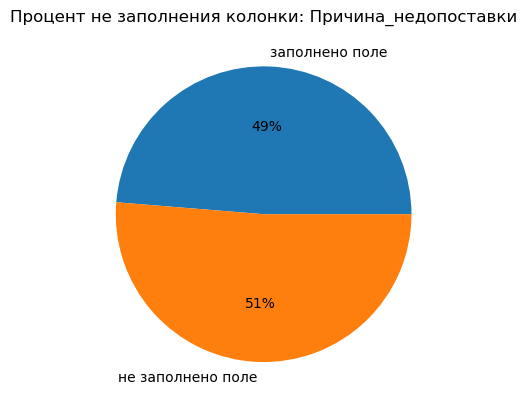

In [202]:
#добавляем столбец с возможной ошибкой: если продажи в сумме соответсвуют 'Global_Sales', то 1, иначе 0
x = 'Причина_недопоставки'
df['нет_причины_недопоставки'] = (df['Причина_недопоставки'] == '').astype(int)
#именуем новую колонку
import numpy as np
df['нет_причины_недопоставки'] = np.where(df['нет_причины_недопоставки'] == 1, 'не заполнено поле', 'заполнено поле')
#получаем требуемую таблицу
series10 = df[['Причина_недопоставки', 'нет_причины_недопоставки']].groupby('нет_причины_недопоставки')['Причина_недопоставки'].count()
#строим круговую диаграмму
plt.pie(series10, labels = series10.index, autopct = '%1.0f%%')
plt.title(f'Процент не заполнения колонки: {x}')
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Причина_причины.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Причина_причины.png']

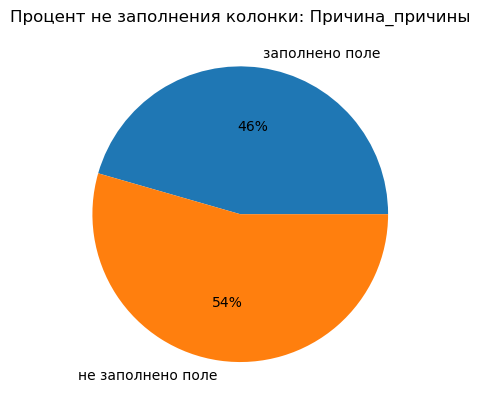

In [203]:
#добавляем столбец с возможной ошибкой: если продажи в сумме соответсвуют 'Global_Sales', то 1, иначе 0
x = 'Причина_причины'
df[f'нет {x}'] = (df[x] == '').astype(int)
#именуем новую колонку
import numpy as np
df[f'нет {x}'] = np.where(df[f'нет {x}'] == 1, 'не заполнено поле', 'заполнено поле')
#получаем требуемую таблицу
series10 = df[[x, f'нет {x}']].groupby(f'нет {x}')[x].count()
#строим круговую диаграмму
plt.pie(series10, labels = series10.index, autopct = '%1.0f%%')
plt.title(f'Процент не заполнения колонки: {x}')
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Ответственное_подразделение.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Ответственное_подразделение.png']

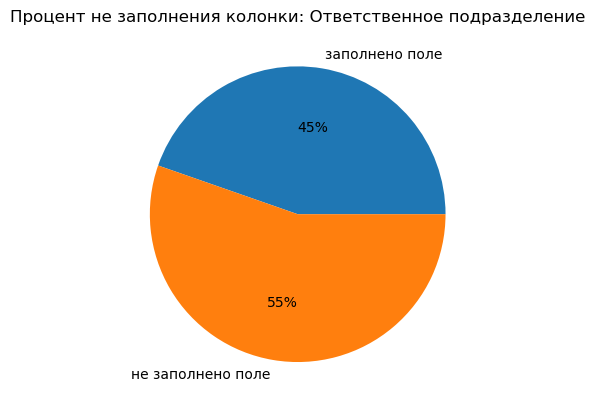

In [204]:
#добавляем столбец с возможной ошибкой: если продажи в сумме соответсвуют 'Global_Sales', то 1, иначе 0
x = 'Ответственное подразделение'
df[f'нет {x}'] = (df[x] == '').astype(int)
#именуем новую колонку
import numpy as np
df[f'нет {x}'] = np.where(df[f'нет {x}'] == 1, 'не заполнено поле', 'заполнено поле')
#получаем требуемую таблицу
series10 = df[[x, f'нет {x}']].groupby(f'нет {x}')[x].count()
#строим круговую диаграмму
plt.pie(series10, labels = series10.index, autopct = '%1.0f%%')
plt.title(f'Процент не заполнения колонки: {x}')
# Сохранение во всех основных форматах
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
plt.savefig(f" График_{x}  от {current_time}.png", dpi=150, bbox_inches='tight')  # Для почты и веба
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

График сохранен: C:\users\user0907\SQL_Import\График_Комментарий_от_2025_09_18_12_27_33.png


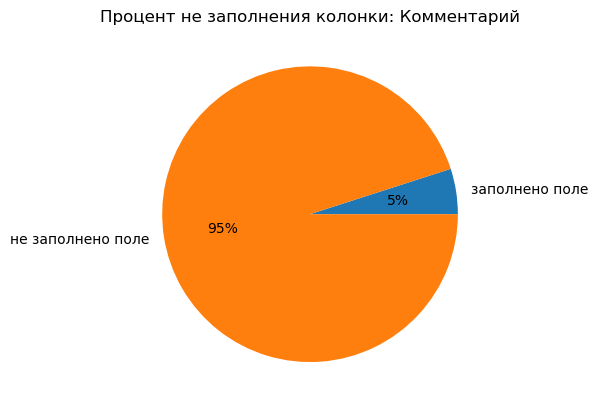

In [168]:
#добавляем столбец с возможной ошибкой: если продажи в сумме соответсвуют 'Global_Sales', то 1, иначе 0
x = 'Комментарий'
df[f'нет {x}'] = (df[x] == '').astype(int)
#именуем новую колонку
import numpy as np
df[f'нет {x}'] = np.where(df[f'нет {x}'] == 1, 'не заполнено поле', 'заполнено поле')
#получаем требуемую таблицу
series10 = df[[x, f'нет {x}']].groupby(f'нет {x}')[x].count()
#строим круговую диаграмму
plt.pie(series10, labels = series10.index, autopct = '%1.0f%%')
plt.title(f'Процент не заполнения колонки: {x}')
#задаем путь к файлам для записи логов
import os
from datetime import datetime
current_time = datetime.now().strftime('%Y_%m_%d %H_%M_%S')
base_dir = r"C:\users\user0907"
output_path = os.path.join(base_dir, 'SQL_Import')

# Создаем папку, если она не существует
os.makedirs(output_path, exist_ok=True)

# Генерируем имя файла с текущим временем
current_time = datetime.now().strftime('%Y_%m_%d_%H_%M_%S')
output_file = os.path.join(output_path, f"График_{x}_от_{current_time}.png")

# Сохранение во всех основных форматах

plt.savefig(output_file, dpi=150, bbox_inches='tight', facecolor='white')  # Для почты и веба
print(f"График сохранен: {output_file}")
#plt.savefig(f"График_{x}  от {current_time}.pdf", bbox_inches='tight')           # Для печати
#plt.savefig(f"График_{x}  от {current_time}.svg", bbox_inches='tight')           # Для редактирования


Сохранен PNG: C:\Users\user0907\SQL_Import\2025-09-18\план-факт-кз\Отклонение.png


['C:\\Users\\user0907\\SQL_Import\\2025-09-18\\план-факт-кз\\Отклонение.png']

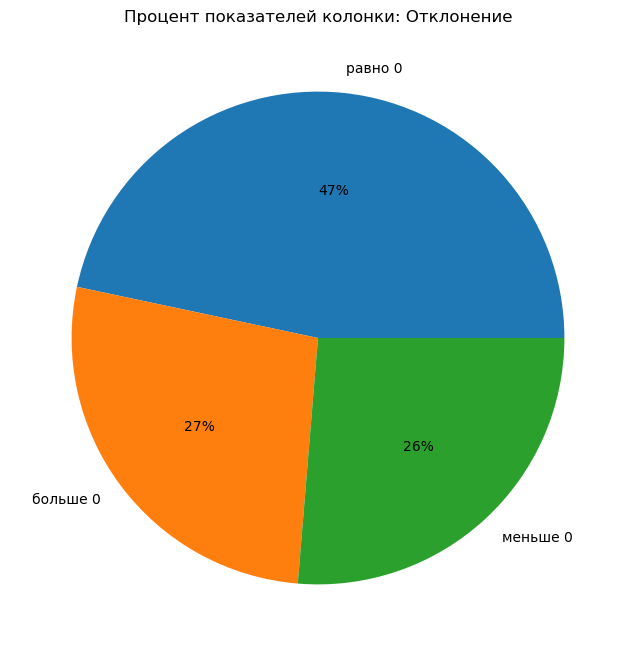

In [205]:
#добавляем столбец с возможной ошибкой: если продажи в сумме соответсвуют 'Global_Sales', то 1, иначе 0
x = 'Отклонение'

# Создаем столбец с категориями отклонения
df[f'статус {x}'] = np.where(df[x] < 0, 'меньше 0',
                    np.where(df[x] > 0, 'больше 0', 'равно 0'))
# Получаем статистику по категориям отклонения
status_counts = df[f'статус {x}'].value_counts()

# Строим круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.0f%%')
plt.title(f'Процент показателей колонки: {x}')
advanced_save(block_name="план-факт-кз", 
             plot_name=x)

In [1]:
df_bank = pd.read_csv('https://www.dropbox.com/s/62m9ymoaunnfg6/bank')
df_bank.head()

NameError: name 'pd' is not defined